# **DS 4002 Project 2 Code**

In the following notebook, we provide step-by-step instructions on how to reproduce our results. Run the code cells in the order specified. Where applicable, steps may be skipped as directed.



In [ ]:
""" Step 1: Connect to Cloud
The following cell prompts a Google Colab notebook to open GAuth and connect to Google Drive. Ensure that all necessary files for the notebook are saved here alongside
the notebook itself. If running on a local instance, download the files to the same folder as the notebook and use 'import os' and 'os.chdir()' to redirect the working
directory.

"""

from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/Colab Notebooks
#change 'Colab Notebooks' to the remaining file path to the required files within Google Drive

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Colab Notebooks


In [ ]:
""" Step 2: install (if necessary) and import dependencies
The following cell imports all the packages necessary for this notebook. If an error or warning prompts that a package is uninstalled, install that package via the pip
installer.

"""
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [ ]:
""" Step 3: load in PJM data
The following cell references the files as retrieved and renamed from PJM dataminer2 and concatenates them into one workable data frame. On the PJM dataminer2 website
provided in our references, select the ranges indicated and download as .csv. Please rename each file to match the provided schema.
"""
load_2024_df = pd.read_csv("load_data_2024.csv") # 01/01/2024 to 12/31/2024
load_2025_df = pd.read_csv("load_data_2025.csv") # 01/01/2025 to 12/31/2025
load_2026_df = pd.read_csv("load_data_2026.csv") # 01/01/2026 to 02/28/2026

#concatenates the three dataframes together
load_df = pd.concat([load_2024_df,load_2025_df,load_2026_df])


In [ ]:
""" Step 4: filter loaded PJM data
The following cell filters the PJM data to only encompass the region of interest (e.g. Dominion Energy) and converts the time stamps to Eastern Standard Time. Warnings
can be ignored.
"""

#filter data to include only the target region
dominion_load = load_df[(load_df['zone']=='DOM') & (load_df['load_area']=='DOM')]

#now that data is filtered, drop location columns and is_verified column (all entries come from verified provider)
hourly_load_data = dominion_load[['datetime_beginning_utc','datetime_beginning_ept','mw']]

#convert date columns to datetime and then to Eastern Standard Time
hourly_load_data['beginning_utc_in_datetime'] = pd.to_datetime(hourly_load_data["datetime_beginning_utc"], errors="coerce")
hourly_load_data["beginning_est_in_datetime"] = hourly_load_data['beginning_utc_in_datetime'].dt.tz_localize('UTC').dt.tz_convert('US/Eastern')

#extract date componenet of new column for later merging
hourly_load_data['beginning_date'] = hourly_load_data['beginning_est_in_datetime'].dt.date


/tmp/ipykernel_18467/3098173069.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hourly_load_data['beginning_utc_in_datetime'] = pd.to_datetime(hourly_load_data["datetime_beginning_utc"], errors="coerce")
/tmp/ipykernel_18467/3098173069.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hourly_load_data["beginning_est_in_datetime"] = hourly_load_data['beginning_utc_in_datetime'].dt.tz_localize('UTC').dt.tz_convert('US/Eastern')
/tmp/ipykernel_18467/3098173069.py:17: SettingWithCopyWarning: 
A value is

In [ ]:
""" Step 5: load in NOAA weather data
The following cell references a data file retrieved by order from NOAA's Climate Data Online tool for the stations indicated by the print() statement.
"""
weather_df = pd.read_csv('weather_data_2024_to_2026.csv')
print(np.unique(weather_df['STATION']))

['US1VAAB0010' 'US1VAAB0012' 'US1VAAB0021' 'US1VACRC002' 'USC00441593'
 'USC00443213' 'USW00003759']


In [ ]:
""" Step 6: clean and group weather data
The following cell filters out any missing values in the columns of interest (e.g. TMAX, TMIN, PRCP), groups the data by date, and takes the mean of the columns of
interest for each date. The cell also converts each date to a format matching that of the PJM data.
"""
#drop nas and unnecessary columns
cleaned_weather_df = weather_df[(weather_df['TMAX'].notna()) & (weather_df['TMIN'].notna()) & (weather_df['PRCP'].notna())]
cleaned_weather_df = cleaned_weather_df[['STATION','NAME','DATE','PRCP','TMIN','TMAX']]

#group weather data by date and take the mean of the given columns at each date
grouped_weather_data = cleaned_weather_df.groupby('DATE')[['PRCP','TMIN','TMAX']].mean().reset_index()
grouped_weather_data.columns = ['DATE','PRCP','TMIN','TMAX']

#convert date to required format
grouped_weather_data['beginning_date'] = pd.to_datetime(grouped_weather_data['DATE'],errors="coerce").dt.date


In [ ]:
""" Step 7: merge the PJM data with the grouped weather data
The following cell merges grouped_weather_data and load_df on the 'beginning_date' column, keeping only the relevant columns.
"""
merged_data = pd.merge(hourly_load_data,grouped_weather_data,how='left',on='beginning_date')
merged_data = merged_data[['beginning_est_in_datetime','mw','PRCP','TMIN','TMAX']]

In [ ]:
""" Step 8: ensure equal spacing of timepoints, one hot encode time aspects, and engineer lag features
The following cell sets Eastern Standard Time as the index for easy referencing; creates dummy columns representing hours, day of the week (e.g. Monday, Tuesday, etc.),
and months; and engineers lag features using a shift of 'x' hours.
"""
#set the time column to index and ensure rows are spaced on a continuous hourly basis
final_data = merged_data.set_index("beginning_est_in_datetime")
final_data = final_data.sort_index()
final_data = final_data.asfreq("h")

#create temporary columns extracting hour, day of week, and month from time index
final_data['hour'] = final_data.index.hour
final_data['day_of_week'] = final_data.index.dayofweek
final_data['month'] = final_data.index.month

#create dummies from columns created above and append to data
hour_dummies = pd.get_dummies(final_data['hour'],prefix='hour',drop_first=True).astype(int) #first hour is dropped
day_of_week_dummies = pd.get_dummies(final_data['day_of_week'],prefix='dow',drop_first=True).astype(int) #Monday is dropped
month_dummies = pd.get_dummies(final_data['month'],prefix='month',drop_first=True).astype(int) #January is dropped
final_data = pd.concat([final_data, hour_dummies, day_of_week_dummies, month_dummies], axis = 1)

#create lag features using .shift
final_data['lag_1'] = final_data['mw'].shift(1) #shifts MW data down 1 row
final_data['lag_2'] = final_data['mw'].shift(2) #shifts MW data down 2 row
final_data['lag_24'] = final_data['mw'].shift(24) #shifts MW data down 24 row
final_data['lag_48'] = final_data['mw'].shift(48) #shifts MW data down 48 row
final_data['lag_168'] = final_data['mw'].shift(168) #shifts MW data down 168 row

#drop any rows made unusable by na in lag features and drop temporary columns
final_data = final_data.dropna()
final_data = final_data.drop(['hour','day_of_week','month'],axis=1)

final_data


,mw,PRCP,TMIN,TMAX,hour_1,hour_2,hour_3,hour_4,hour_5,hour_6,...,month_8,month_9,month_10,month_11,month_12,lag_1,lag_2,lag_24,lag_48,lag_168
beginning_est_in_datetime,,,,,,,,,,,,,,,,,,,,,
2024-01-08 00:00:00-05:00,13422.199,0.0,29.0,49.333333,0,0,0,0,0,0,...,0,0,0,0,0,13717.329,14143.233,14219.113,15537.692,13553.438
2024-01-08 01:00:00-05:00,13386.288,0.0,29.0,49.333333,1,0,0,0,0,0,...,0,0,0,0,0,13422.199,13717.329,14148.764,15310.903,13455.698
2024-01-08 02:00:00-05:00,13402.781,0.0,29.0,49.333333,0,1,0,0,0,0,...,0,0,0,0,0,13386.288,13422.199,14052.406,15203.210,13325.136
2024-01-08 03:00:00-05:00,13702.942,0.0,29.0,49.333333,0,0,1,0,0,0,...,0,0,0,0,0,13402.781,13386.288,14079.011,15063.314,13302.830
2024-01-08 04:00:00-05:00,14239.843,0.0,29.0,49.333333,0,0,0,1,0,0,...,0,0,0,0,0,13702.942,13402.781,14177.716,15067.077,13453.881
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-28 19:00:00-05:00,14722.158,0.0,39.0,59.500000,0,0,0,0,0,0,...,0,0,0,0,0,14584.413,14040.509,16369.322,16679.178,15578.246
2026-02-28 20:00:00-05:00,14633.298,0.0,39.0,59.500000,0,0,0,0,0,0,...,0,0,0,0,0,14722.158,14584.413,16270.537,16496.709,15580.648
2026-02-28 21:00:00-05:00,14461.693,0.0,39.0,59.500000,0,0,0,0,0,0,...,0,0,0,0,0,14633.298,14722.158,16076.187,16150.419,15442.172


In [ ]:
""" Step 9: define test and train sets
The following cell defines the time boundaries of the train and test set and subsequently divides the data accordingly.

"""
#set the boundaries
train_start_date = "2024-01-01 00:00:00-5:00" # min 2024-01-01 00:00:00-5:00
train_end_date = "2025-12-31 00:00:00-5:00" # MUST be BEFORE test_start_date
test_start_date = "2026-01-01 00:00:00-5:00" # MUST be AFTER train_end_date
test_end_date = "2026-02-28 00:00:00-5:00" # max 2026-02-28 23:00:00-5:00

#divide data accordingly
train = final_data[(final_data.index >= train_start_date) & (final_data.index <= train_end_date)]
test = final_data[(final_data.index >= test_start_date) & (final_data.index <= test_end_date)]

#target variable set
y_train = train['mw']
y_test = test['mw']

#feature variables set
X_train = train.drop(['mw'],axis=1)
X_test = test.drop(['mw'],axis=1)

In [ ]:
""" Step 10: visual diagnostic function
The following cell defines a function for visualizing predictions.
"""
import matplotlib.ticker as mtick
import matplotlib.dates as mdates

# NOTE: I AM STILL WORKING ON THIS

def visualize_predictions(y,forecast,label):
  plt.figure(figsize=(12,5))
  #remove spines and set bottom to correct color
  for side in ['top','left','right']:
    plt.gca().spines[side].set_visible(False)
  plt.gca().spines['bottom'].set_color("black")
  #add gridlines
  plt.grid(axis='y',color='gray',alpha=0.1)
  #format into GW ticks on y axis
  plt.ylim(12000,26000)
  plt.gca().yaxis.set_major_locator(mtick.MaxNLocator(nbins=7))
  plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_:f'{x/1000:.1f}'))

  plt.gca().tick_params(axis='x',rotation=45)
  plt.plot(y.index,forecast,label=f'{label} Forecast',alpha=0.5)
  plt.plot(y.index,y,label='Actual',alpha=0.5)
  plt.xlabel("Date")
  plt.ylabel("Electricity Demand (in GW)")
  plt.legend()
  plt.title(f"{label} Forecast",pad=15)
  plt.show()

RMSE (ARIMA):  2847.692407459322
MAE (ARIMA):  2182.8107109853595


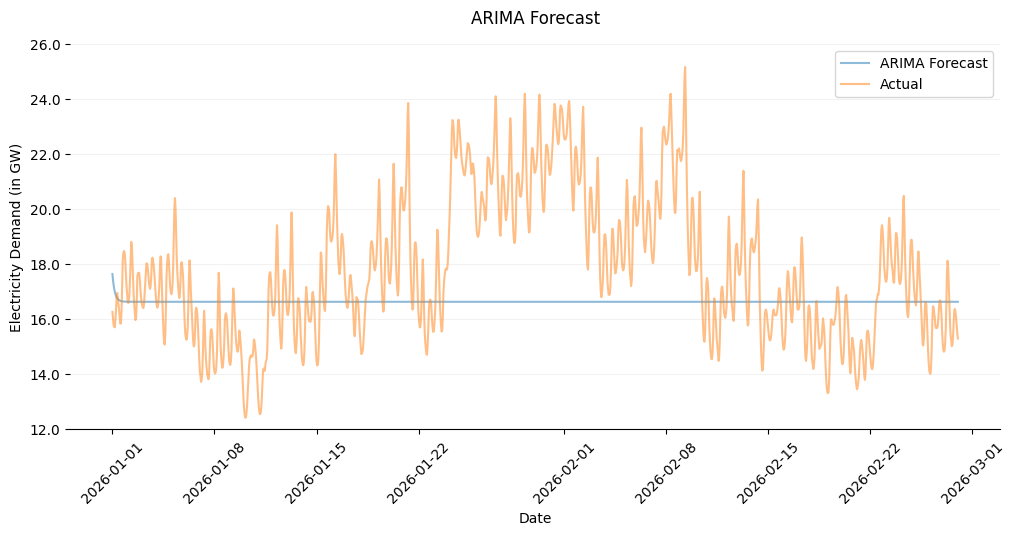

In [ ]:
""" Step 11: perform baseline ARIMA
The following cell implements an ARIMA model using the train and test sets and subsequently presents the results.

"""
arima_model_no_exogs = ARIMA(y_train, order=(1,1,1))
arima_results_no_exogs = arima_model_no_exogs.fit()

arima_forecast_no_exogs = arima_results_no_exogs.forecast(steps=len(y_test))
rmse_arima_no_exogs = np.sqrt(mean_squared_error(y_test,arima_forecast_no_exogs))
mae_arima_no_exogs = mean_absolute_error(y_test,arima_forecast_no_exogs)

print("RMSE (ARIMA): ", rmse_arima_no_exogs)
print("MAE (ARIMA): ", mae_arima_no_exogs)

visualize_predictions(y_test,arima_forecast_no_exogs,label='ARIMA')


RMSE (ARIMAX):  2864.518700730234
MAE (ARIMAX):  2190.09374402732


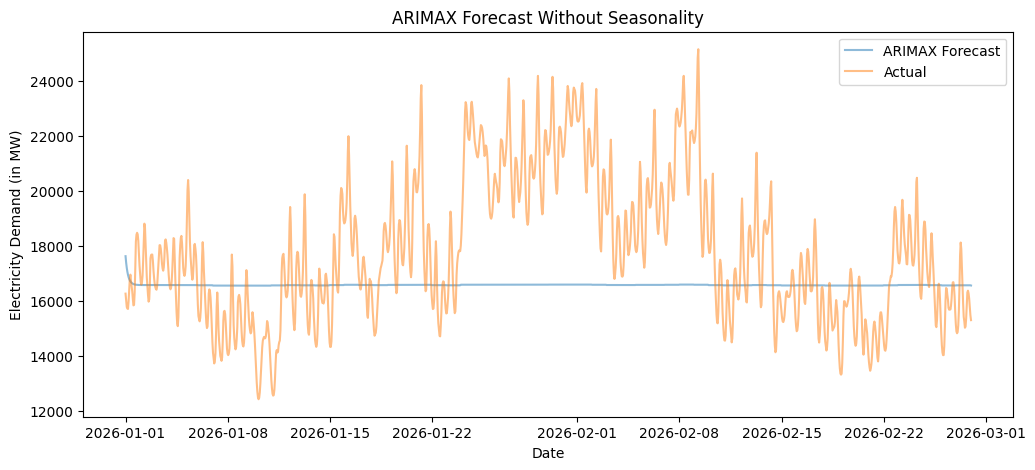

RMSE (SARIMAX):  2543.8548714054773
MAE (SARIMAX):  2026.81349243201


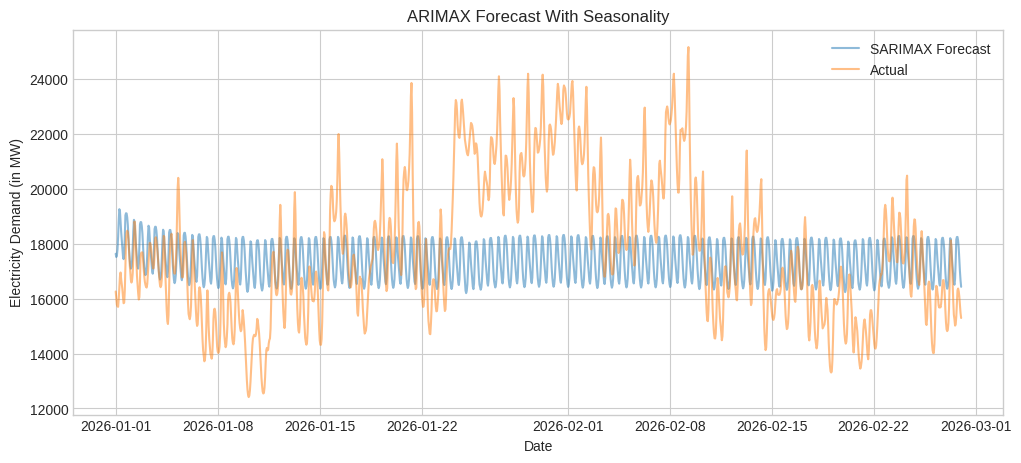

In [ ]:
""" Step 11: perform baseline ARIMAX and seasonal ARIMAX
The following cell implements an ARIMAX model and a SARIMAX model using the train and test sets and subsequently presents the results.

"""
# --------------------------------------------------------------- ARIMAX - WITHOUT SEASONALITY ------------------------------------------------------------------------- #
arimax_model = SARIMAX(y_train,exog=X_train[['PRCP','TMAX','TMIN']],order=(1,1,1),enforce_invertibility=False,enforce_stationarity=False)
arimax_results = arimax_model.fit()

arimax_forecast = arimax_results.forecast(steps=len(y_test),exog=X_test[['PRCP','TMAX','TMIN']])
rmse_arimax = np.sqrt(mean_squared_error(y_test,arimax_forecast))
mae_arimax = mean_absolute_error(y_test,arimax_forecast)

print("RMSE (ARIMAX): ", rmse_arimax)
print("MAE (ARIMAX): ", mae_arimax)

plt.figure(figsize=(12,5))
plt.plot(y_test.index,arimax_forecast,label='ARIMAX Forecast',alpha=0.5)
plt.plot(y_test.index,y_test,label='Actual',alpha=0.5)
plt.xlabel("Date")
plt.ylabel("Electricity Demand (in MW)")
plt.legend()
plt.title("ARIMAX Forecast Without Seasonality")
plt.show()

# --------------------------------------------------------------- ARIMAX - WITH SEASONALITY ---------------------------------------------------------------------------- #

sarimax_model = SARIMAX(y_train,order=(1,0,1),exog=X_train[['PRCP','TMAX','TMIN']],seasonal_order=(0,1,1,24),enforce_invertibility=False,enforce_stationarity=False)
sarimax_results = sarimax_model.fit(maxiter=200,disp=False)

sarimax_forecast = sarimax_results.forecast(steps=len(y_test),exog=X_test[['PRCP','TMAX','TMIN']])
rmse_sarimax = np.sqrt(mean_squared_error(y_test,sarimax_forecast))
mae_sarimax = mean_absolute_error(y_test,sarimax_forecast)

print("RMSE (SARIMAX): ", rmse_sarimax)
print("MAE (SARIMAX): ", mae_sarimax)

plt.figure(figsize=(12,5))
plt.plot(y_test.index,sarimax_forecast,label='SARIMAX Forecast',alpha=0.5)
plt.plot(y_test.index,y_test,label='Actual',alpha=0.5)
plt.xlabel("Date")
plt.ylabel("Electricity Demand (in MW)")
plt.legend()
plt.title("ARIMAX Forecast With Seasonality")
plt.show()

RMSE (no exogs):  273.78407097762766
MAE (no exogs):  187.61951642980418


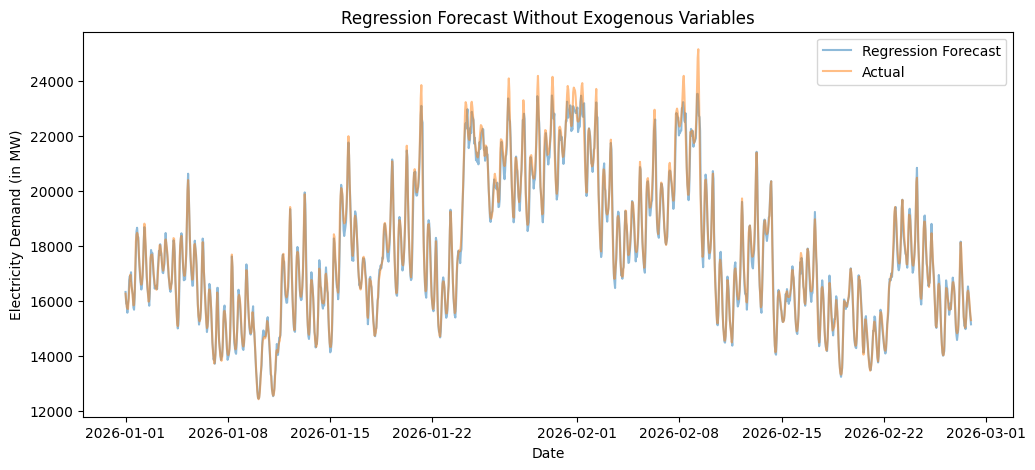

RMSE (with exogs):  248.98277914090633
MAE (with exogs):  173.9547020009001


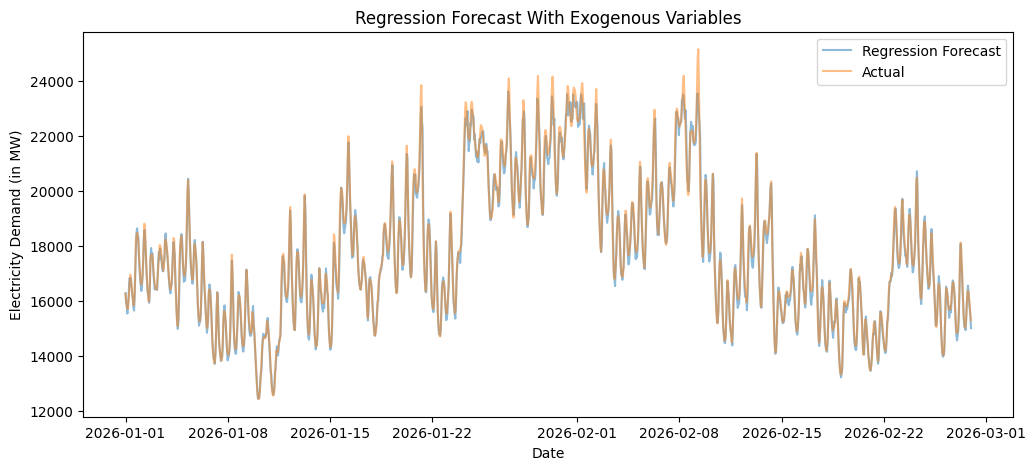

In [ ]:
""" Step 12: perform regression with and without exogenous variables
The following cell implements an regression model without exogenous variables and a regression model with exogenous variables using the train and test sets and
subsequently presents the results.

"""
# --------------------------------------------------------------- REGRESSION - WITHOUT EXOGS -------------------------------------------------------------------------- #
regression_model_no_exogs = HistGradientBoostingRegressor(
    loss="squared_error",
    learning_rate=0.05,
    max_iter=300,
    max_depth=6,
    min_samples_leaf=30,
    random_state=4002
) #instantiate the model
regression_model_no_exogs.fit(X=X_train.drop(['TMAX','TMIN','PRCP'],axis=1),y=y_train) #train the model

#diagnostics
predictions_no_exogs = regression_model_no_exogs.predict(X_test.drop(['TMAX','TMIN','PRCP'],axis=1))
rmse_no_exogs = np.sqrt(mean_squared_error(y_test, predictions_no_exogs))
mae_no_exogs = mean_absolute_error(y_test, predictions_no_exogs)

print("RMSE (no exogs): ", rmse_no_exogs)
print("MAE (no exogs): ", mae_no_exogs)

#plotting
plt.figure(figsize=(12,5))
plt.plot(y_test.index,predictions_no_exogs,label='Regression Forecast',alpha=0.5)
plt.plot(y_test.index,y_test,label='Actual',alpha=0.5)
plt.xlabel("Date")
plt.ylabel("Electricity Demand (in MW)")
plt.legend()
plt.title("Regression Forecast Without Exogenous Variables")
plt.show()

# --------------------------------------------------------------- REGRESSION - WITH EXOGS ----------------------------------------------------------------------------- #
regression_model_with_exogs = HistGradientBoostingRegressor(
    loss="squared_error",
    learning_rate=0.05,
    max_iter=300,
    max_depth=6,
    min_samples_leaf=30,
    random_state=4002
) #instantiate the model
regression_model_with_exogs.fit(X=X_train,y=y_train) #train the model

#diagnostics
predictions_with_exogs = regression_model_with_exogs.predict(X_test)
rmse_with_exogs = np.sqrt(mean_squared_error(y_test, predictions_with_exogs))
mae_with_exogs = mean_absolute_error(y_test, predictions_with_exogs)

print("RMSE (with exogs): ", rmse_with_exogs)
print("MAE (with exogs): ", mae_with_exogs)

#plotting
plt.figure(figsize=(12,5))
plt.plot(y_test.index,predictions_with_exogs,label='Regression Forecast',alpha=0.5)
plt.plot(y_test.index,y_test,label='Actual',alpha=0.5)
plt.xlabel("Date")
plt.ylabel("Electricity Demand (in MW)")
plt.legend()
plt.title("Regression Forecast With Exogenous Variables")
plt.show()

In [ ]:
""" Step 13: export final data
The following cell exports the final data to .csv.
"""

Exploratory Visualizations:

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
load_df = pd.read_csv("hrl_load_metered.csv")
weather_df = pd.read_csv("4252944.csv")

# Keep only Dominion load area
dom_df = load_df[load_df["load_area"] == "DOM"].copy()

# Convert datetime column
dom_df["datetime_beginning_ept"] = pd.to_datetime(dom_df["datetime_beginning_ept"])

# Sort values
dom_df = dom_df.sort_values("datetime_beginning_ept")

# Create a date column for merging with daily weather data
dom_df["DATE"] = dom_df["datetime_beginning_ept"].dt.date

# Daily average load
daily_load = dom_df.groupby("DATE", as_index=False)["mw"].mean()
daily_load["DATE"] = pd.to_datetime(daily_load["DATE"])
daily_load.rename(columns={"mw": "daily_avg_load_mw"}, inplace=True)

# Prepare weather data
weather_df["DATE"] = pd.to_datetime(weather_df["DATE"])

# Keep useful weather columns
weather_keep = weather_df[["DATE", "PRCP", "TMAX", "TMIN", "TOBS"]].copy()

# If there are duplicate dates from multiple stations, average them by date
weather_daily = weather_keep.groupby("DATE", as_index=False).mean()

# Merge daily load with daily weather
merged_df = pd.merge(daily_load, weather_daily, on="DATE", how="inner")

print(dom_df.head())
print(daily_load.head())
print(weather_daily.head())
print(merged_df.head())
print(merged_df.isnull().sum())

/tmp/ipykernel_811/2165033908.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dom_df["datetime_beginning_ept"] = pd.to_datetime(dom_df["datetime_beginning_ept"])


    datetime_beginning_utc datetime_beginning_ept nerc_region mkt_region zone  \
10     1/1/2025 5:00:00 AM    2025-01-01 00:00:00        SERC      SOUTH  DOM   
40     1/1/2025 6:00:00 AM    2025-01-01 01:00:00        SERC      SOUTH  DOM   
70     1/1/2025 7:00:00 AM    2025-01-01 02:00:00        SERC      SOUTH  DOM   
100    1/1/2025 8:00:00 AM    2025-01-01 03:00:00        SERC      SOUTH  DOM   
130    1/1/2025 9:00:00 AM    2025-01-01 04:00:00        SERC      SOUTH  DOM   

    load_area         mw  is_verified        DATE  
10        DOM  12464.698         True  2025-01-01  
40        DOM  12350.936         True  2025-01-01  
70        DOM  12218.446         True  2025-01-01  
100       DOM  12219.991         True  2025-01-01  
130       DOM  12352.585         True  2025-01-01  
        DATE  daily_avg_load_mw
0 2025-01-01       13544.428958
1 2025-01-02       15787.834708
2 2025-01-03       16766.270458
3 2025-01-04       17535.726542
4 2025-01-05       17775.602583
        D

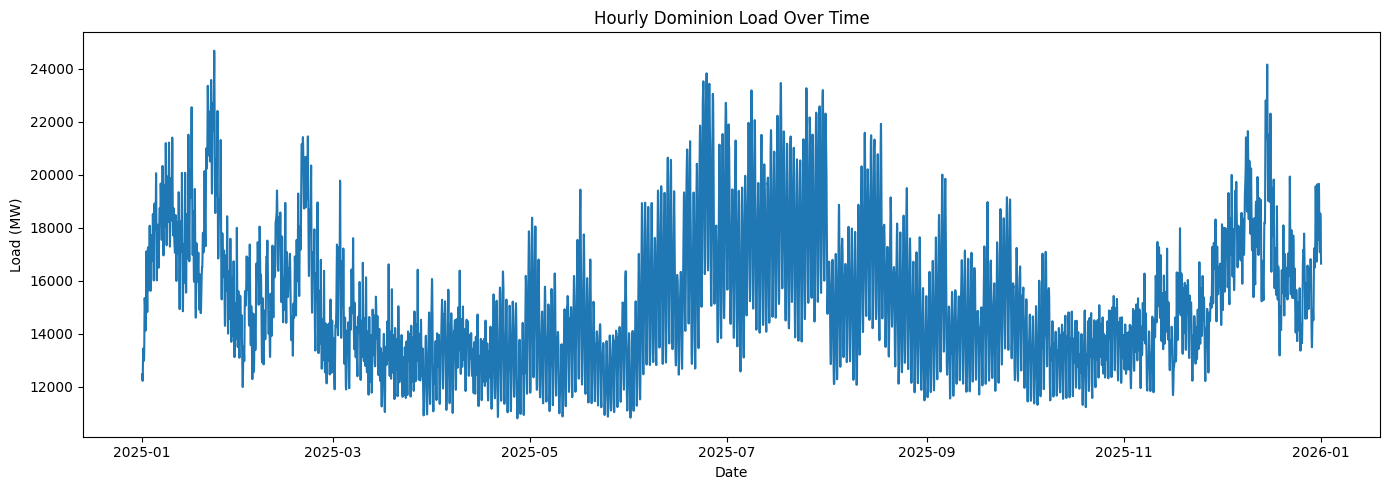

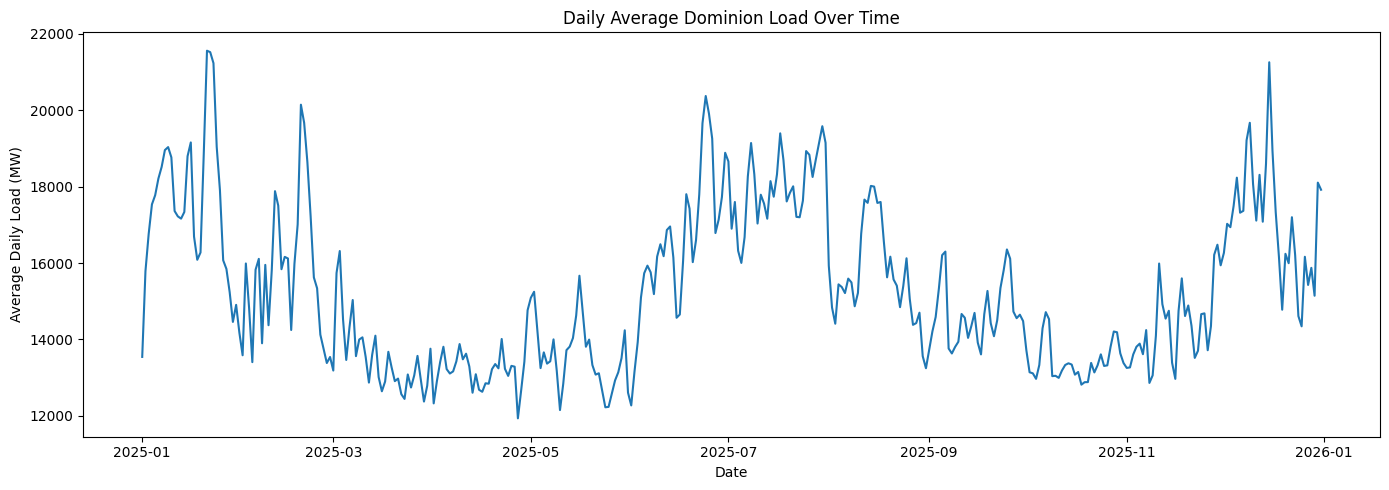

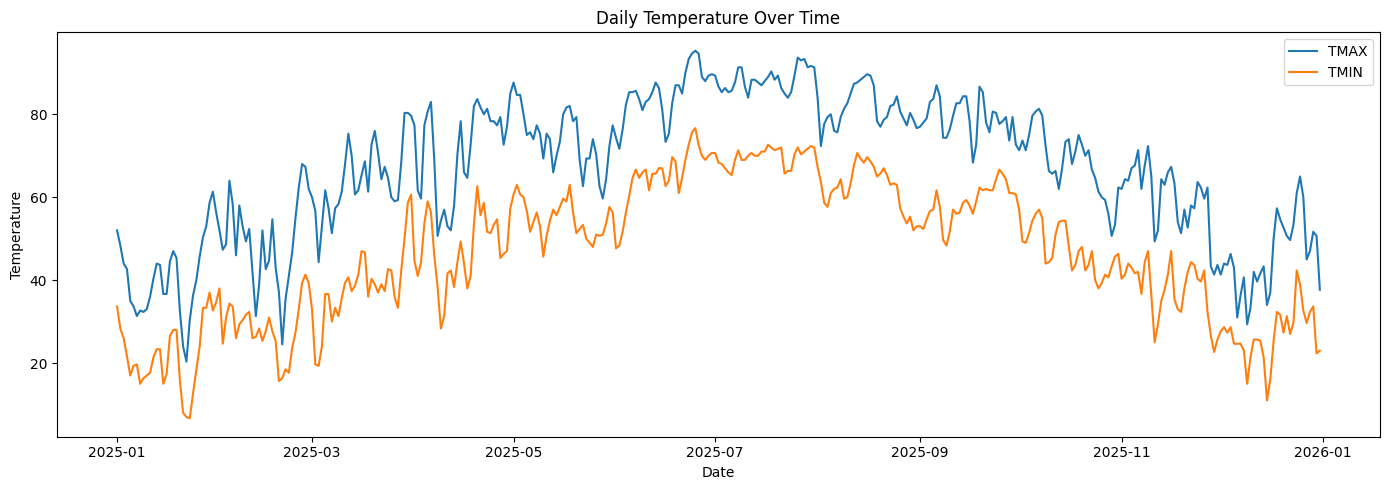

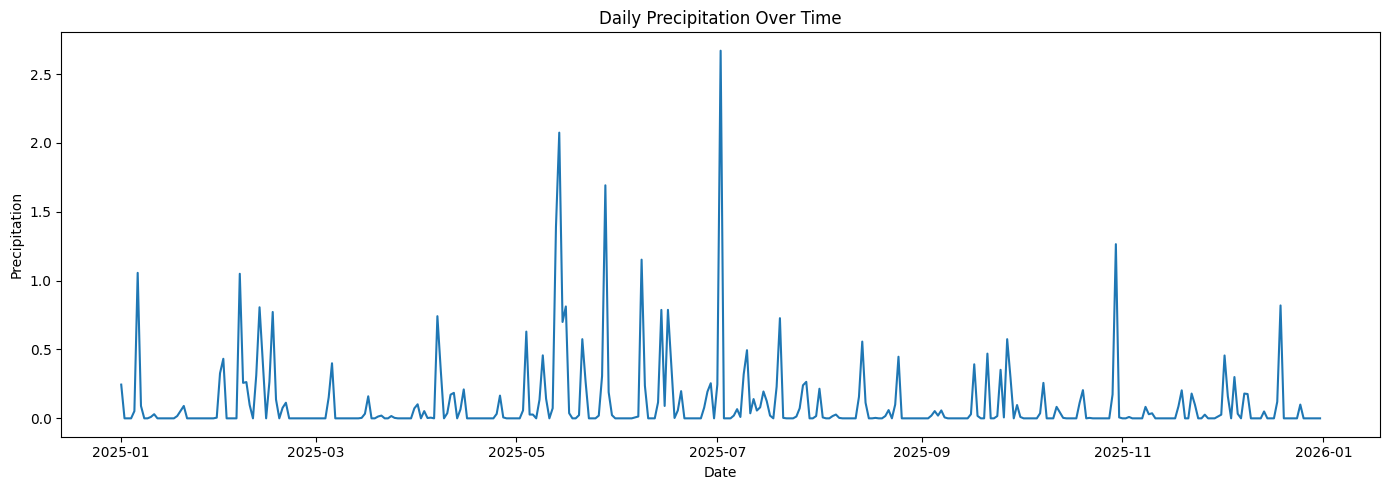

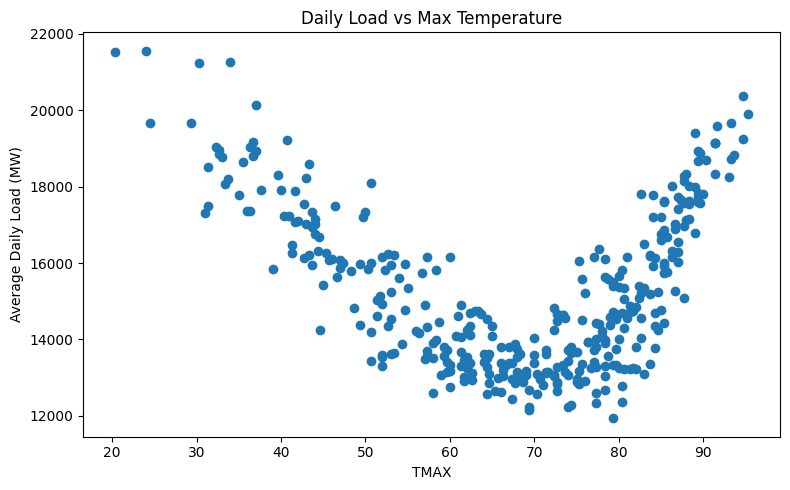

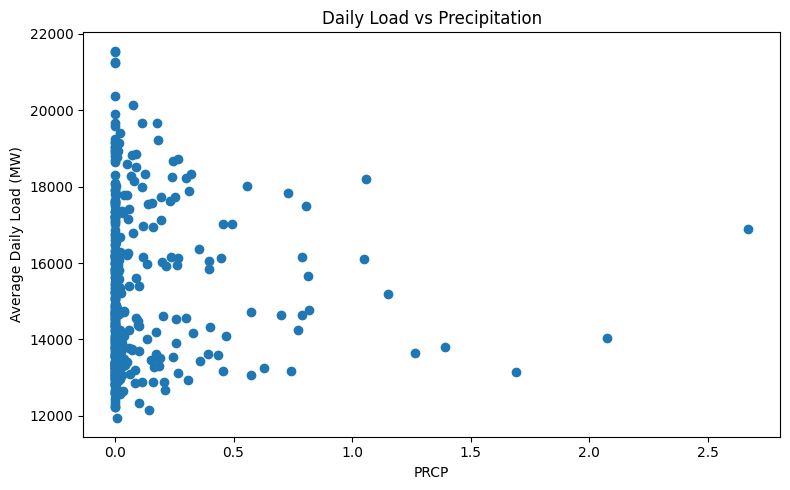

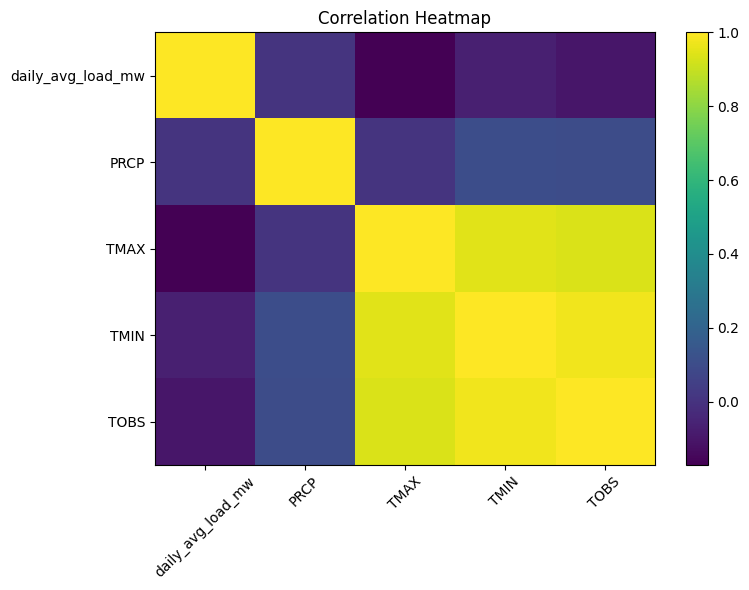

In [ ]:
# Hourly Dominion load over time
plt.figure(figsize=(14, 5))
plt.plot(dom_df["datetime_beginning_ept"], dom_df["mw"])
plt.title("Hourly Dominion Load Over Time")
plt.xlabel("Date")
plt.ylabel("Load (MW)")
plt.tight_layout()
plt.show()

# Daily average Dominion load over time
plt.figure(figsize=(14, 5))
plt.plot(merged_df["DATE"], merged_df["daily_avg_load_mw"])
plt.title("Daily Average Dominion Load Over Time")
plt.xlabel("Date")
plt.ylabel("Average Daily Load (MW)")
plt.tight_layout()
plt.show()

# Daily temperature over time
plt.figure(figsize=(14, 5))
plt.plot(merged_df["DATE"], merged_df["TMAX"], label="TMAX")
plt.plot(merged_df["DATE"], merged_df["TMIN"], label="TMIN")
plt.title("Daily Temperature Over Time")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.legend()
plt.tight_layout()
plt.show()

# Daily precipitation over time
plt.figure(figsize=(14, 5))
plt.plot(merged_df["DATE"], merged_df["PRCP"])
plt.title("Daily Precipitation Over Time")
plt.xlabel("Date")
plt.ylabel("Precipitation")
plt.tight_layout()
plt.show()

# Scatterplot: load vs max temperature
plt.figure(figsize=(8, 5))
plt.scatter(merged_df["TMAX"], merged_df["daily_avg_load_mw"])
plt.title("Daily Load vs Max Temperature")
plt.xlabel("TMAX")
plt.ylabel("Average Daily Load (MW)")
plt.tight_layout()
plt.show()

# Scatterplot: load vs precipitation
plt.figure(figsize=(8, 5))
plt.scatter(merged_df["PRCP"], merged_df["daily_avg_load_mw"])
plt.title("Daily Load vs Precipitation")
plt.xlabel("PRCP")
plt.ylabel("Average Daily Load (MW)")
plt.tight_layout()
plt.show()

# Correlation heatmap
corr_cols = ["daily_avg_load_mw", "PRCP", "TMAX", "TMIN", "TOBS"]
corr_matrix = merged_df[corr_cols].corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr_cols)), corr_cols, rotation=45)
plt.yticks(range(len(corr_cols)), corr_cols)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()